In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200/"

os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 200

X = []
y = []

for nama_kelas, label in kelas_files.items():

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(0, len(data)-window+1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print(nama_kelas, ":", total_window)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = scaler.transform(X_test_2d).reshape(
    X_test.shape[0],
    timestep,
    fitur
)

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("GYRO ONLY 200 selesai")

diam : 300
jalan : 300
diamjatuh : 300
jalanjatuh : 300
Shape X : (1200, 200, 3)
Shape y : (1200,)
GYRO ONLY 200 selesai


Train : (960, 200, 3)
Test  : (240, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 10: finished saving model to best_model_gyro_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6667 - loss: 0.7350 - val_accuracy: 0.4688 - val_loss: 1.4595 - learning_rate: 5.0000e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6540 - loss: 0.7662
Epoch 11: val_accuracy did not improve from 0.46875
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6523 - loss: 0.7582 - val_accuracy: 0.4688 - val_loss: 1.4573 - learning_rate: 5.0000e-04
Epoch 12/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6730 - loss: 0.6757
Epoch 12: val_accuracy improved from 0.46875 to 0.47396, saving model to best_model_gyro_only_200.h5



Epoch 12: finished saving model to best_model_gyro_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6823 - loss: 0.6840 - val_accuracy: 0.4740 - val_loss: 1.5069 - learning_rate: 5.0000e-04
Epoch 13/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7243 - loss: 0.6099
Epoch 13: val_accuracy improved from 0.47396 to 0.48438, saving model to best_model_gyro_only_200.h5



Epoch 13: finished saving model to best_model_gyro_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7018 - loss: 0.6343 - val_accuracy: 0.4844 - val_loss: 1.4804 - learning_rate: 5.0000e-04
Epoch 14/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6881 - loss: 0.6728
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: val_accuracy improved from 0.48438 to 0.49479, saving model to best_model_gyro_only_200.h5



Epoch 14: finished saving model to best_model_gyro_only_200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6927 - loss: 0.6804 - val_accuracy: 0.4948 - val_loss: 1.5426 - learning_rate: 5.0000e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4208 - loss: 1.2253
TEST ACCURACY : 42.08 %
TEST LOSS     : 1.2253
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.38      0.93      0.54        60
       jalan       0.45      0.62      0.52        60
   diamjatuh       0.00      0.00      0.00        60
  jalanjatuh       1.00      0.13      0.24        60

    accuracy                           0.42       240
   macro avg       0.46      0.42      0.32       240
weighted avg       0.46      0.42      0.32       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


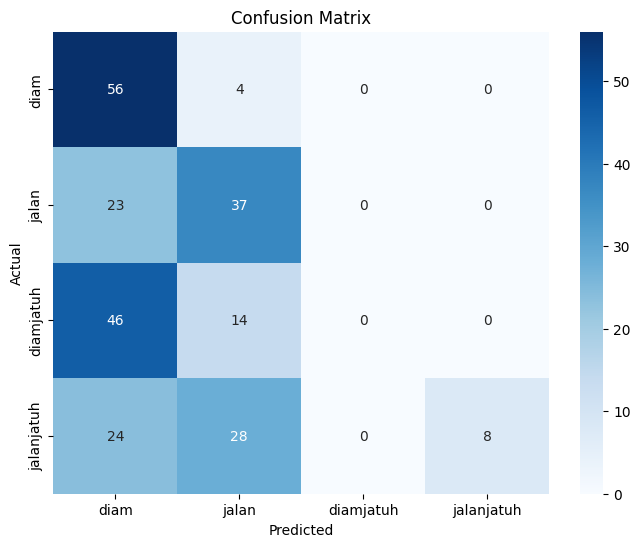

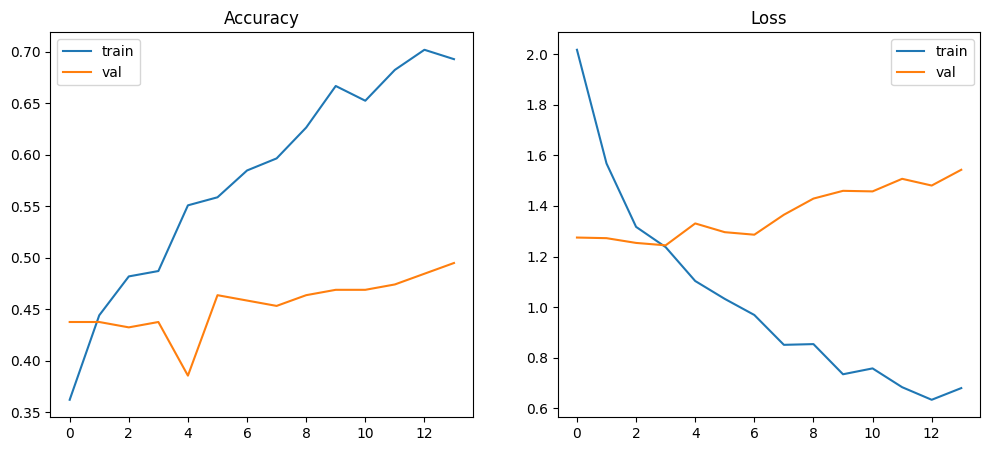

In [ ]:
# TRAINING CNN GYRO ONLY 200

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_200.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='val'
)

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 300

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_300/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 300
stride = 300

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY Window 300 selesai")

Processing: diam
Window: 200
Processing: jalan
Window: 200
Processing: diamjatuh
Window: 200
Processing: jalanjatuh
Window: 200
Shape X : (800, 300, 3)
Shape y : (800,)
Train : (640, 300, 3)
Test  : (160, 300, 3)
Dataset GYRO ONLY Window 300 selesai


Train : (640, 300, 3)
Test  : (160, 300, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 296, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,404 (2.34 MB)

...


Epoch 1: finished saving model to best_model_gyro_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.3652 - loss: 1.9832 - val_accuracy: 0.4844 - val_loss: 1.2561 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5550 - loss: 1.3250
Epoch 2: val_accuracy improved from 0.48438 to 0.54688, saving model to best_model_gyro_only_300.h5



Epoch 2: finished saving model to best_model_gyro_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5000 - loss: 1.4862 - val_accuracy: 0.5469 - val_loss: 1.2346 - learning_rate: 0.0010
Epoch 3/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5160 - loss: 1.3036
Epoch 3: val_accuracy improved from 0.54688 to 0.55469, saving model to best_model_gyro_only_300.h5



Epoch 3: finished saving model to best_model_gyro_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5215 - loss: 1.2577 - val_accuracy: 0.5547 - val_loss: 1.2238 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4905 - loss: 1.2350
Epoch 4: val_accuracy improved from 0.55469 to 0.57031, saving model to best_model_gyro_only_300.h5



Epoch 4: finished saving model to best_model_gyro_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5430 - loss: 1.1948 - val_accuracy: 0.5703 - val_loss: 1.2155 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5629 - loss: 1.1497
Epoch 5: val_accuracy did not improve from 0.57031
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5859 - loss: 1.0932 - val_accuracy: 0.5391 - val_loss: 1.1959 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6082 - loss: 0.8622
Epoch 6: val_accuracy did not improve from 0.57031
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5820 - loss: 0.9355 - val_accuracy: 0.4844 - val_loss: 1.2000 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6453 - loss: 0.8987
Epoch 7: val_accuracy did not improve from 0.57031
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6445 - loss: 0.9270 - val_accuracy: 0.2969 - val_los


Epoch 21: finished saving model to best_model_gyro_only_300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7832 - loss: 0.5443 - val_accuracy: 0.5938 - val_loss: 1.3801 - learning_rate: 5.0000e-04
Epoch 22/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8015 - loss: 0.4257
Epoch 22: val_accuracy did not improve from 0.59375
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7930 - loss: 0.4696 - val_accuracy: 0.5625 - val_loss: 1.4242 - learning_rate: 5.0000e-04
Epoch 23/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8083 - loss: 0.4656
Epoch 23: val_accuracy did not improve from 0.59375
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7969 - loss: 0.4722 - val_accuracy: 0.5625 - val_loss: 1.3817 - learning_rate: 5.0000e-04
Epoch 24/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8312 - loss: 0.3790
Epoch 24: val_accuracy did not improve from 0.59375
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8340 - loss: 0.3787 - val_accurac

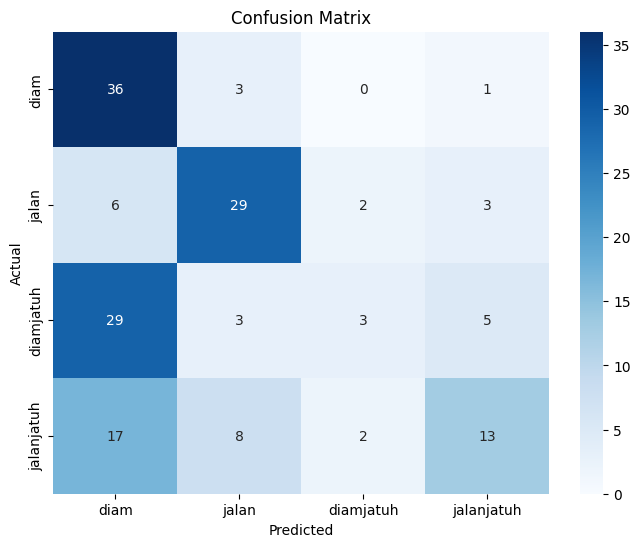

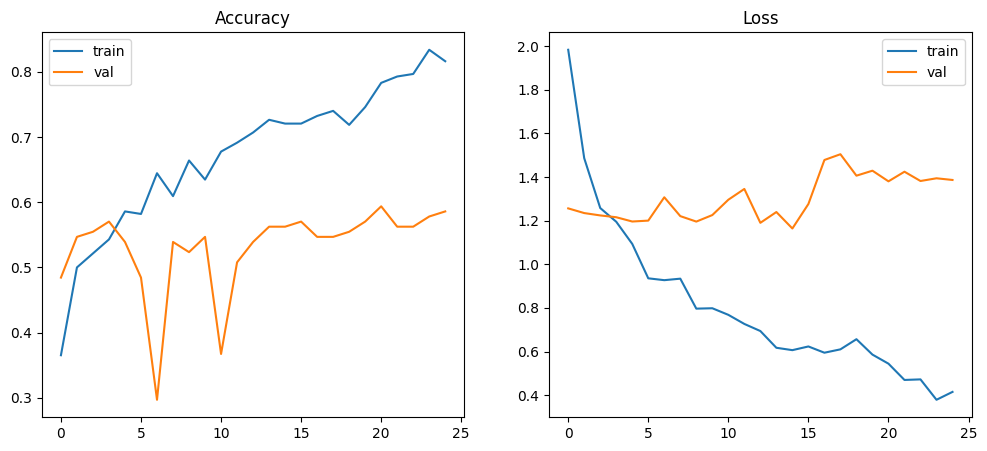

In [ ]:
# TRAINING CNN GYRO ONLY 300

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_300/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_300.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 400

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_400/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 400
stride = 400

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY Window 400 selesai")

Processing: diam
Window: 150
Processing: jalan
Window: 150
Processing: diamjatuh
Window: 150
Processing: jalanjatuh
Window: 150
Shape X : (600, 400, 3)
Shape y : (600,)
Train : (480, 400, 3)
Test  : (120, 400, 3)
Dataset GYRO ONLY Window 400 selesai


Train : (480, 400, 3)
Test  : (120, 400, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 396, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 396, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 196, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 96, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       786,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,396 (3.16 MB)

...

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3269 - loss: 2.4025
Epoch 1: val_accuracy improved from None to 0.52083, saving model to best_model_gyro_only_400.h5



Epoch 1: finished saving model to best_model_gyro_only_400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.3464 - loss: 2.4113 - val_accuracy: 0.5208 - val_loss: 1.2600 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4527 - loss: 2.0228
Epoch 2: val_accuracy improved from 0.52083 to 0.55208, saving model to best_model_gyro_only_400.h5



Epoch 2: finished saving model to best_model_gyro_only_400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4635 - loss: 1.8939 - val_accuracy: 0.5521 - val_loss: 1.1760 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5132 - loss: 1.3660
Epoch 3: val_accuracy did not improve from 0.55208
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5286 - loss: 1.3241 - val_accuracy: 0.5104 - val_loss: 1.1652 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5818 - loss: 1.3212
Epoch 4: val_accuracy did not improve from 0.55208
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5859 - loss: 1.1694 - val_accuracy: 0.4896 - val_loss: 1.1752 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6227 - loss: 1.0169
Epoch 5: val_accuracy did not improve from 0.55208
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.6302 - loss: 1.0269 - val_accuracy: 0.4792 - val_los

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.45      0.83      0.58        30
       jalan       0.53      0.77      0.63        30
   diamjatuh       0.27      0.13      0.18        30
  jalanjatuh       0.50      0.10      0.17        30

    accuracy                           0.46       120
   macro avg       0.44      0.46      0.39       120
weighted avg       0.44      0.46      0.39       120



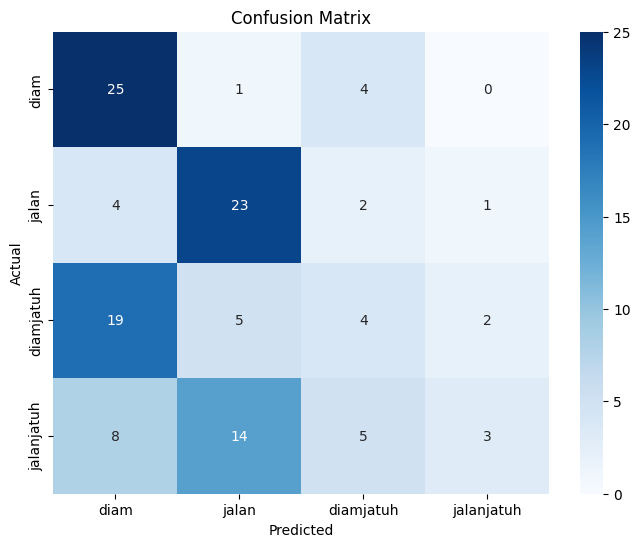

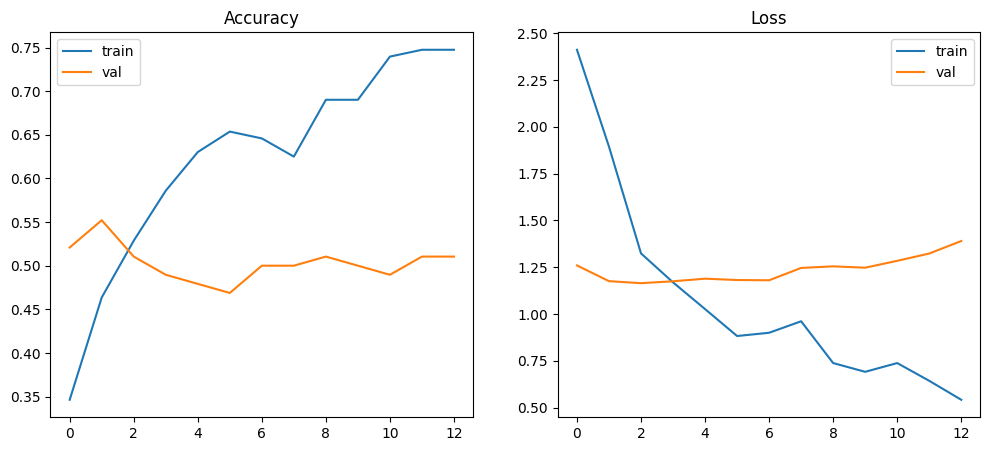

In [ ]:
# TRAINING CNN GYRO ONLY 400

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_400/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(400,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_400.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 150

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_150/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 150
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY Window 150 selesai")

Processing: diam
Window: 400
Processing: jalan
Window: 400
Processing: diamjatuh
Window: 400
Processing: jalanjatuh
Window: 400
Shape X : (1600, 150, 3)
Shape y : (1600,)
Train : (1280, 150, 3)
Test  : (320, 150, 3)
Dataset GYRO ONLY Window 150 selesai


Train : (1280, 150, 3)
Test  : (320, 150, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 146, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 146, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 73, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 71, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 71, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 33, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 33, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,108 (1.16 MB)

...


Epoch 2: finished saving model to best_model_gyro_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4375 - loss: 1.4407 - val_accuracy: 0.4766 - val_loss: 1.2460 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4396 - loss: 1.3333
Epoch 3: val_accuracy did not improve from 0.47656
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4395 - loss: 1.3377 - val_accuracy: 0.4727 - val_loss: 1.2283 - learning_rate: 0.0010
Epoch 4/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4977 - loss: 1.2415
Epoch 4: val_accuracy improved from 0.47656 to 0.49609, saving model to best_model_gyro_only_150.h5



Epoch 4: finished saving model to best_model_gyro_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4902 - loss: 1.2403 - val_accuracy: 0.4961 - val_loss: 1.1804 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4893 - loss: 1.1098
Epoch 5: val_accuracy did not improve from 0.49609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5049 - loss: 1.1082 - val_accuracy: 0.4570 - val_loss: 1.1440 - learning_rate: 0.0010
Epoch 6/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5225 - loss: 1.1030
Epoch 6: val_accuracy did not improve from 0.49609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4912 - loss: 1.1504 - val_accuracy: 0.4766 - val_loss: 1.1527 - learning_rate: 0.0010
Epoch 7/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5581 - loss: 1.0183
Epoch 7: val_accuracy did not improve from 0.49609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5449 - loss: 1.0421 - val_accuracy: 0.4883 - val_los


Epoch 9: finished saving model to best_model_gyro_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5488 - loss: 0.9852 - val_accuracy: 0.5039 - val_loss: 1.1362 - learning_rate: 0.0010
Epoch 10/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5585 - loss: 0.9804
Epoch 10: val_accuracy improved from 0.50391 to 0.50781, saving model to best_model_gyro_only_150.h5



Epoch 10: finished saving model to best_model_gyro_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5508 - loss: 0.9792 - val_accuracy: 0.5078 - val_loss: 1.1298 - learning_rate: 0.0010
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5571 - loss: 0.9134
Epoch 11: val_accuracy did not improve from 0.50781
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5703 - loss: 0.9020 - val_accuracy: 0.5078 - val_loss: 1.1372 - learning_rate: 0.0010
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6105 - loss: 0.8957
Epoch 12: val_accuracy did not improve from 0.50781
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5928 - loss: 0.9244 - val_accuracy: 0.5000 - val_loss: 1.1146 - learning_rate: 0.0010
Epoch 13/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5939 - loss: 0.8955
Epoch 13: val_accuracy did not improve from 0.50781
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5801 - loss: 0.9046 - val_accuracy: 0.4766 - 


Epoch 14: finished saving model to best_model_gyro_only_150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6064 - loss: 0.8658 - val_accuracy: 0.5195 - val_loss: 1.1194 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6284 - loss: 0.8143
Epoch 15: val_accuracy did not improve from 0.51953
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6172 - loss: 0.8346 - val_accuracy: 0.5078 - val_loss: 1.1208 - learning_rate: 0.0010
Epoch 16/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6496 - loss: 0.8114
Epoch 16: val_accuracy did not improve from 0.51953
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6318 - loss: 0.8280 - val_accuracy: 0.4766 - val_loss: 1.2104 - learning_rate: 0.0010
Epoch 17/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6527 - loss: 0.7746
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: val_accuracy did not improve from 0.51953
32/32 ━━━━━━━━━━━━━━━

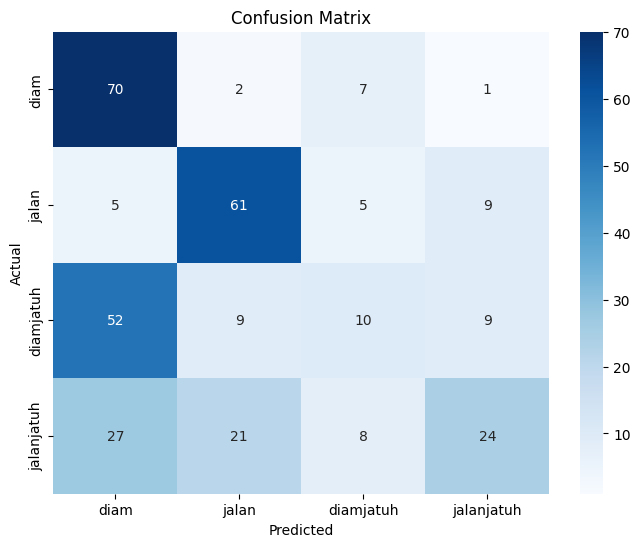

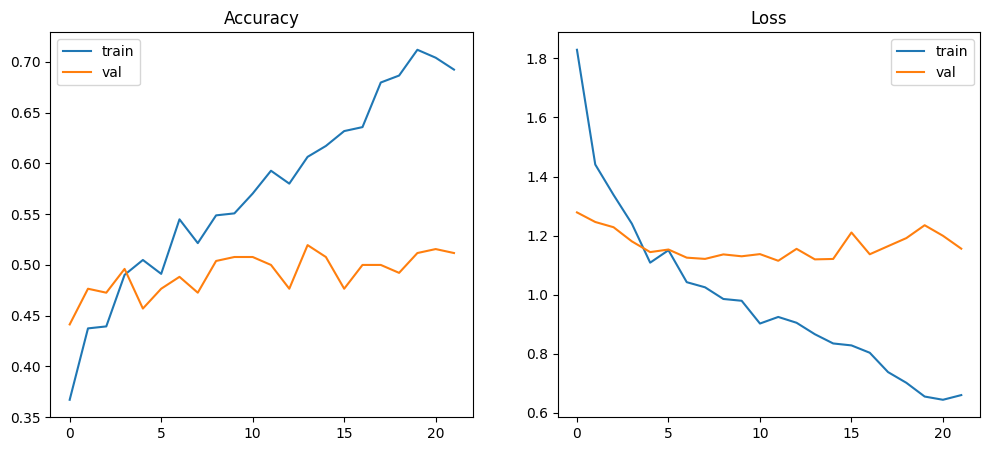

In [ ]:
# TRAINING CNN GYRO ONLY 150

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_150/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(150,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_150.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 250

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_250/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 250
stride = 250

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[
            i:i+window
        ]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY Window 250 selesai")

Processing: diam
Window: 240
Processing: jalan
Window: 240
Processing: diamjatuh
Window: 240
Processing: jalanjatuh
Window: 240
Shape X : (960, 250, 3)
Shape y : (960,)
Train : (768, 250, 3)
Test  : (192, 250, 3)
Dataset GYRO ONLY Window 250 selesai


Train : (768, 250, 3)
Test  : (192, 250, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 246, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 246, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 123, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 121, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 121, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 58, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 58, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       475,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,100 (1.97 MB)

 Trainable params: 515,652 (1.97 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3601 - loss: 1.7989
Epoch 1: val_accuracy improved from None to 0.51948, saving model to best_model_gyro_only_250.h5



Epoch 1: finished saving model to best_model_gyro_only_250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.3827 - loss: 1.9246 - val_accuracy: 0.5195 - val_loss: 1.2569 - learning_rate: 0.0010
Epoch 2/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4293 - loss: 1.8060
Epoch 2: val_accuracy did not improve from 0.51948
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.4365 - loss: 1.7498 - val_accuracy: 0.4091 - val_loss: 1.2704 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4431 - loss: 1.5789
Epoch 3: val_accuracy did not improve from 0.51948
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4788 - loss: 1.4493 - val_accuracy: 0.4740 - val_loss: 1.2608 - learning_rate: 0.0010
Epoch 4/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5144 - loss: 1.1641
Epoch 4: val_accuracy did not improve from 0.51948
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5228 - loss: 1.1951 - val_accuracy: 0.4675 - val_lo

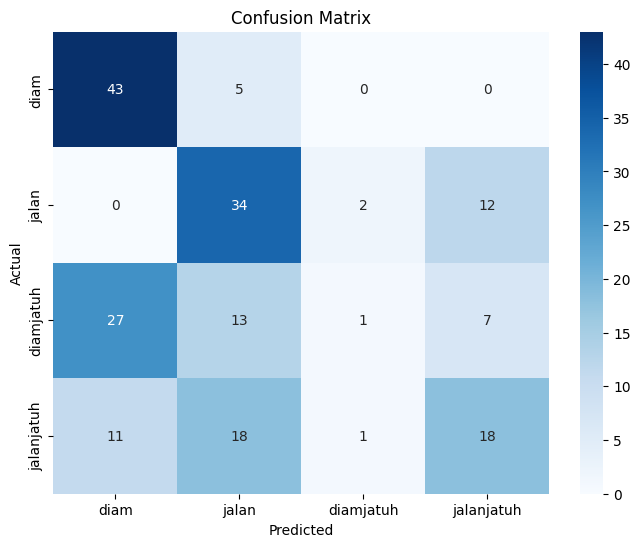

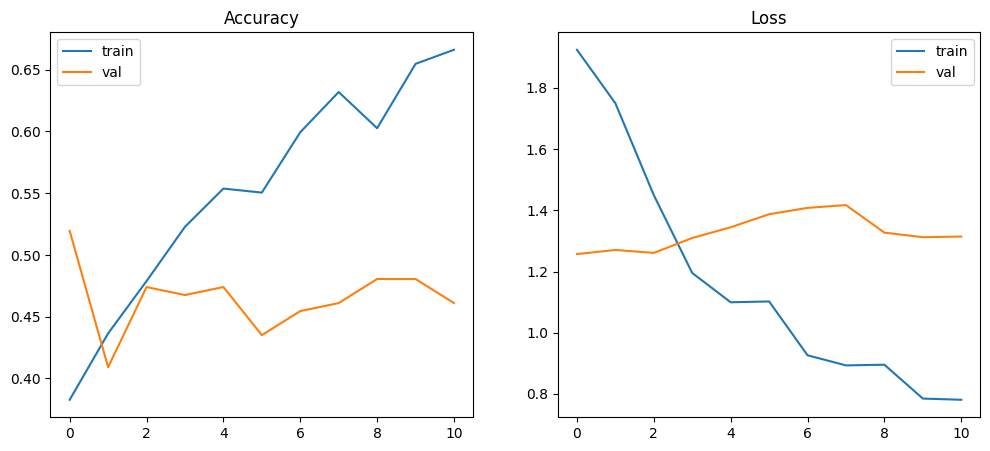

In [ ]:
# TRAINING CNN GYRO ONLY 250

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_250/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(250,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_250.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 200 OVERLAP 50%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap50/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 100

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY 200 overlap 50 selesai")

Processing: diam
Window: 599
Processing: jalan
Window: 599
Processing: diamjatuh
Window: 599
Processing: jalanjatuh
Window: 599
Shape X : (2396, 200, 3)
Shape y : (2396,)
Train : (1916, 200, 3)
Test  : (480, 200, 3)
Dataset GYRO ONLY 200 overlap 50 selesai


Train : (1916, 200, 3)
Test  : (480, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 11: finished saving model to best_model_gyro_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6312 - loss: 0.8327 - val_accuracy: 0.5729 - val_loss: 1.0062 - learning_rate: 0.0010
Epoch 12/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6574 - loss: 0.8047
Epoch 12: val_accuracy did not improve from 0.57292
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6540 - loss: 0.7966 - val_accuracy: 0.5599 - val_loss: 1.0087 - learning_rate: 0.0010
Epoch 13/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6647 - loss: 0.7315
Epoch 13: val_accuracy improved from 0.57292 to 0.59115, saving model to best_model_gyro_only_200_overlap50.h5



Epoch 13: finished saving model to best_model_gyro_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6534 - loss: 0.7670 - val_accuracy: 0.5911 - val_loss: 1.0395 - learning_rate: 0.0010
Epoch 14/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6928 - loss: 0.7081
Epoch 14: val_accuracy improved from 0.59115 to 0.59375, saving model to best_model_gyro_only_200_overlap50.h5



Epoch 14: finished saving model to best_model_gyro_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6749 - loss: 0.7420 - val_accuracy: 0.5938 - val_loss: 1.0376 - learning_rate: 0.0010
Epoch 15/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6737 - loss: 0.7094
Epoch 15: val_accuracy did not improve from 0.59375
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6789 - loss: 0.7291 - val_accuracy: 0.5859 - val_loss: 1.0017 - learning_rate: 0.0010
Epoch 16/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6810 - loss: 0.7010
Epoch 16: val_accuracy did not improve from 0.59375
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6730 - loss: 0.7432 - val_accuracy: 0.5703 - val_loss: 1.0726 - learning_rate: 0.0010
Epoch 17/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6684 - loss: 0.6977
Epoch 17: val_accuracy did not improve from 0.59375
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6789 - loss: 0.7047 - val_accuracy:


Epoch 23: finished saving model to best_model_gyro_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7820 - loss: 0.5012 - val_accuracy: 0.5964 - val_loss: 1.0514 - learning_rate: 5.0000e-04
Epoch 24/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7843 - loss: 0.4966
Epoch 24: val_accuracy improved from 0.59635 to 0.60156, saving model to best_model_gyro_only_200_overlap50.h5



Epoch 24: finished saving model to best_model_gyro_only_200_overlap50.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7728 - loss: 0.5014 - val_accuracy: 0.6016 - val_loss: 1.0602 - learning_rate: 5.0000e-04
Epoch 25/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7704 - loss: 0.5030
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: val_accuracy did not improve from 0.60156
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7728 - loss: 0.4900 - val_accuracy: 0.6016 - val_loss: 1.0703 - learning_rate: 5.0000e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5562 - loss: 1.0240
TEST ACCURACY : 55.62 %
TEST LOSS     : 1.024
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.49      0.73      0.58       120
       jalan       0.73      0.75      0.74       120
   diamjatuh       0.39      0.30      0.34       120
  jalanjatuh       0

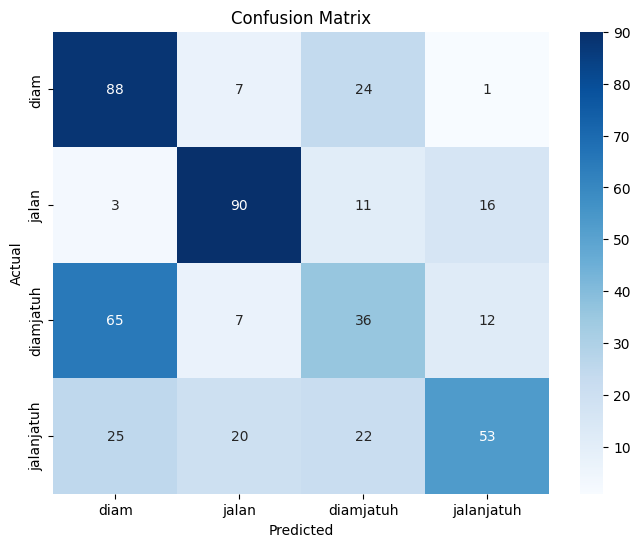

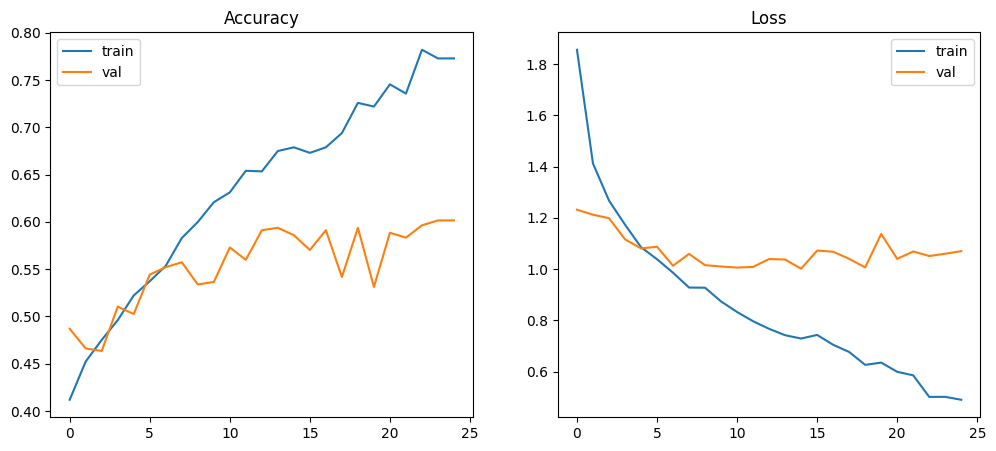

In [ ]:
# TRAINING CNN GYRO ONLY 200 OVERLAP 50%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap50/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_200_overlap50.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 300 OVERLAP 50%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_300_overlap50/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 300
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY 300 overlap 50 selesai")

Processing: diam
Window: 399
Processing: jalan
Window: 399
Processing: diamjatuh
Window: 399
Processing: jalanjatuh
Window: 399
Shape X : (1596, 300, 3)
Shape y : (1596,)
Train : (1276, 300, 3)
Test  : (320, 300, 3)
Dataset GYRO ONLY 300 overlap 50 selesai


Train : (1276, 300, 3)
Test  : (320, 300, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 296, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,404 (2.34 MB)

...


Epoch 17: finished saving model to best_model_gyro_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7598 - loss: 0.5380 - val_accuracy: 0.5234 - val_loss: 1.1514 - learning_rate: 5.0000e-04
Epoch 18/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7795 - loss: 0.5163
Epoch 18: val_accuracy improved from 0.52344 to 0.53906, saving model to best_model_gyro_only_300_overlap50.h5



Epoch 18: finished saving model to best_model_gyro_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7725 - loss: 0.5417 - val_accuracy: 0.5391 - val_loss: 1.1365 - learning_rate: 5.0000e-04
Epoch 19/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7820 - loss: 0.5148
Epoch 19: val_accuracy improved from 0.53906 to 0.55859, saving model to best_model_gyro_only_300_overlap50.h5



Epoch 19: finished saving model to best_model_gyro_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7784 - loss: 0.5146 - val_accuracy: 0.5586 - val_loss: 1.1710 - learning_rate: 5.0000e-04
Epoch 20/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7529 - loss: 0.5358
Epoch 20: val_accuracy did not improve from 0.55859
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7578 - loss: 0.5237 - val_accuracy: 0.5469 - val_loss: 1.1882 - learning_rate: 5.0000e-04
Epoch 21/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7858 - loss: 0.4608
Epoch 21: val_accuracy did not improve from 0.55859
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.7961 - loss: 0.4694 - val_accuracy: 0.5352 - val_loss: 1.2460 - learning_rate: 5.0000e-04
Epoch 22/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7972 - loss: 0.4661
Epoch 22: val_accuracy improved from 0.55859 to 0.56641, saving model to best_model_gyro_only_300_overlap50.h5



Epoch 22: finished saving model to best_model_gyro_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.7961 - loss: 0.4647 - val_accuracy: 0.5664 - val_loss: 1.2027 - learning_rate: 5.0000e-04
Epoch 23/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7800 - loss: 0.4764
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_accuracy did not improve from 0.56641
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7882 - loss: 0.4764 - val_accuracy: 0.5508 - val_loss: 1.2895 - learning_rate: 5.0000e-04
Epoch 24/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8360 - loss: 0.3989
Epoch 24: val_accuracy did not improve from 0.56641
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8382 - loss: 0.3970 - val_accuracy: 0.5469 - val_loss: 1.2573 - learning_rate: 2.5000e-04
Epoch 25/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8364 - loss: 0.4017
Epoch 25: val_accuracy did not improve from 0.56641


Epoch 26: finished saving model to best_model_gyro_only_300_overlap50.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.8255 - loss: 0.3999 - val_accuracy: 0.5703 - val_loss: 1.2374 - learning_rate: 2.5000e-04
Epoch 27/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8397 - loss: 0.3669
Epoch 27: val_accuracy did not improve from 0.57031
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.8431 - loss: 0.3586 - val_accuracy: 0.5391 - val_loss: 1.2559 - learning_rate: 2.5000e-04
Epoch 28/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8500 - loss: 0.3811
Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 28: val_accuracy did not improve from 0.57031
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8520 - loss: 0.3573 - val_accuracy: 0.5391 - val_loss: 1.3337 - learning_rate: 2.5000e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5531 - loss: 1.1059
TEST ACCURACY : 55.31 %
TEST LOSS     : 1.1059
10/10 ━━━━━━━━━━━

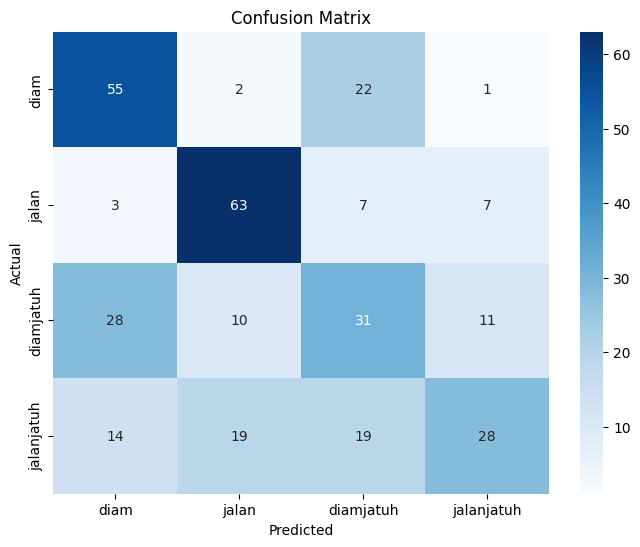

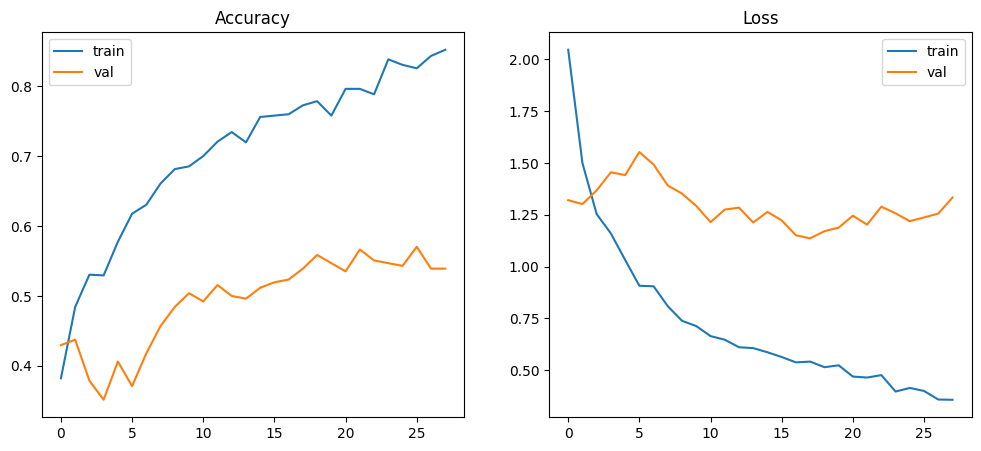

In [ ]:
# TRAINING CNN GYRO ONLY 300 OVERLAP 50%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_300_overlap50/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_300_overlap50.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 200 OVERLAP 25%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap25/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY 200 overlap 25 selesai")

Processing: diam
Window: 399
Processing: jalan
Window: 399
Processing: diamjatuh
Window: 399
Processing: jalanjatuh
Window: 399
Shape X : (1596, 200, 3)
Shape y : (1596,)
Train : (1276, 200, 3)
Test  : (320, 200, 3)
Dataset GYRO ONLY 200 overlap 25 selesai


Train : (1276, 200, 3)
Test  : (320, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 9: finished saving model to best_model_gyro_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6137 - loss: 0.9027 - val_accuracy: 0.4688 - val_loss: 1.1994 - learning_rate: 0.0010
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6255 - loss: 0.8185
Epoch 10: val_accuracy improved from 0.46875 to 0.49219, saving model to best_model_gyro_only_200_overlap25.h5



Epoch 10: finished saving model to best_model_gyro_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6225 - loss: 0.8529 - val_accuracy: 0.4922 - val_loss: 1.1749 - learning_rate: 0.0010
Epoch 11/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6542 - loss: 0.7581
Epoch 11: val_accuracy did not improve from 0.49219
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6471 - loss: 0.8016 - val_accuracy: 0.4883 - val_loss: 1.1812 - learning_rate: 0.0010
Epoch 12/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6532 - loss: 0.8238
Epoch 12: val_accuracy did not improve from 0.49219
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6520 - loss: 0.8047 - val_accuracy: 0.4844 - val_loss: 1.2497 - learning_rate: 0.0010
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6846 - loss: 0.7243
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: val_accuracy improved from 0.49219 to 0.52734, saving


Epoch 13: finished saving model to best_model_gyro_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6716 - loss: 0.7574 - val_accuracy: 0.5273 - val_loss: 1.1895 - learning_rate: 0.0010
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6979 - loss: 0.7078
Epoch 14: val_accuracy did not improve from 0.52734
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6853 - loss: 0.7338 - val_accuracy: 0.5195 - val_loss: 1.1400 - learning_rate: 5.0000e-04
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7161 - loss: 0.6190
Epoch 15: val_accuracy improved from 0.52734 to 0.53125, saving model to best_model_gyro_only_200_overlap25.h5



Epoch 15: finished saving model to best_model_gyro_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7176 - loss: 0.6198 - val_accuracy: 0.5312 - val_loss: 1.1280 - learning_rate: 5.0000e-04
Epoch 16/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7067 - loss: 0.6508
Epoch 16: val_accuracy did not improve from 0.53125
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7127 - loss: 0.6600 - val_accuracy: 0.5312 - val_loss: 1.1910 - learning_rate: 5.0000e-04
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7515 - loss: 0.5987
Epoch 17: val_accuracy did not improve from 0.53125
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7480 - loss: 0.6066 - val_accuracy: 0.5273 - val_loss: 1.1636 - learning_rate: 5.0000e-04
Epoch 18/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7131 - loss: 0.6291
Epoch 18: val_accuracy did not improve from 0.53125
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7206 - loss: 0.6208 - v


Epoch 21: finished saving model to best_model_gyro_only_200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7716 - loss: 0.5312 - val_accuracy: 0.5469 - val_loss: 1.1866 - learning_rate: 2.5000e-04
Epoch 22/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7999 - loss: 0.4955
Epoch 22: val_accuracy did not improve from 0.54688
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7843 - loss: 0.5115 - val_accuracy: 0.5469 - val_loss: 1.2037 - learning_rate: 2.5000e-04
Epoch 23/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7933 - loss: 0.4703
Epoch 23: val_accuracy did not improve from 0.54688
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7784 - loss: 0.4890 - val_accuracy: 0.5391 - val_loss: 1.1972 - learning_rate: 2.5000e-04
Epoch 24/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8039 - loss: 0.4704
Epoch 24: val_accuracy did not improve from 0.54688
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7922 - loss: 0.4882 - v

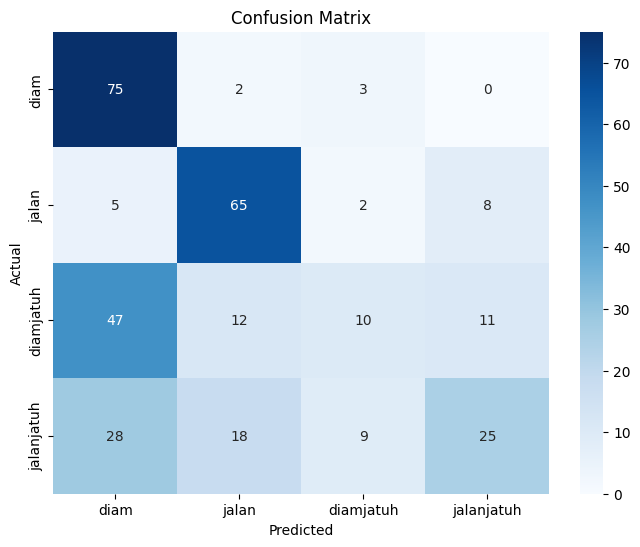

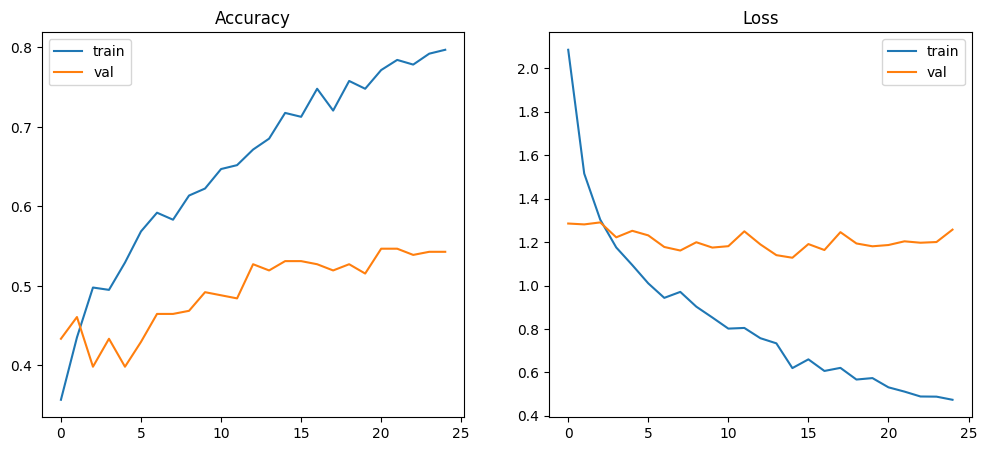

In [ ]:
# TRAINING CNN GYRO ONLY 200 OVERLAP 25%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap25/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_200_overlap25.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING GYRO ONLY
# WINDOW 200 OVERLAP 75%

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"
save_path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap75/"

os.makedirs(
    save_path,
    exist_ok=True
)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 50

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df[[
        "gx",
        "gy",
        "gz"
    ]].values

    total_window = 0

    for i in range(
        0,
        len(data)-window+1,
        stride
    ):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    fitur
)

X_test_2d = X_test.reshape(
    -1,
    fitur
)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train = X_train_scaled.reshape(

    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(

    X_test.shape[0],
    timestep,
    fitur
)

np.save(
    save_path + "X_train.npy",
    X_train
)

np.save(
    save_path + "X_test.npy",
    X_test
)

np.save(
    save_path + "y_train.npy",
    y_train
)

np.save(
    save_path + "y_test.npy",
    y_test
)

joblib.dump(
    scaler,
    save_path + "scaler.save"
)

print("Dataset GYRO ONLY 200 overlap 75 selesai")

Processing: diam
Window: 1197
Processing: jalan
Window: 1197
Processing: diamjatuh
Window: 1197
Processing: jalanjatuh
Window: 1197
Shape X : (4788, 200, 3)
Shape y : (4788,)
Train : (3830, 200, 3)
Test  : (958, 200, 3)
Dataset GYRO ONLY 200 overlap 75 selesai


Train : (3830, 200, 3)
Test  : (958, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,796 (1.59 MB)

...


Epoch 17: finished saving model to best_model_gyro_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6828 - loss: 0.7206 - val_accuracy: 0.6070 - val_loss: 0.9599 - learning_rate: 0.0010
Epoch 18/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7093 - loss: 0.6540
Epoch 18: val_accuracy improved from 0.60705 to 0.61097, saving model to best_model_gyro_only_200_overlap75.h5



Epoch 18: finished saving model to best_model_gyro_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7089 - loss: 0.6444 - val_accuracy: 0.6110 - val_loss: 0.9485 - learning_rate: 5.0000e-04
Epoch 19/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7248 - loss: 0.6178
Epoch 19: val_accuracy did not improve from 0.61097
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7262 - loss: 0.6143 - val_accuracy: 0.6070 - val_loss: 1.0157 - learning_rate: 5.0000e-04
Epoch 20/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7255 - loss: 0.6141
Epoch 20: val_accuracy improved from 0.61097 to 0.61358, saving model to best_model_gyro_only_200_overlap75.h5



Epoch 20: finished saving model to best_model_gyro_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7307 - loss: 0.6033 - val_accuracy: 0.6136 - val_loss: 1.0069 - learning_rate: 5.0000e-04
Epoch 21/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7520 - loss: 0.5615
Epoch 21: val_accuracy improved from 0.61358 to 0.61488, saving model to best_model_gyro_only_200_overlap75.h5



Epoch 21: finished saving model to best_model_gyro_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7507 - loss: 0.5639 - val_accuracy: 0.6149 - val_loss: 0.9906 - learning_rate: 5.0000e-04
Epoch 22/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7462 - loss: 0.5530
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: val_accuracy improved from 0.61488 to 0.61880, saving model to best_model_gyro_only_200_overlap75.h5



Epoch 22: finished saving model to best_model_gyro_only_200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7549 - loss: 0.5468 - val_accuracy: 0.6188 - val_loss: 1.0063 - learning_rate: 5.0000e-04
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5814 - loss: 0.9120
TEST ACCURACY : 58.14 %
TEST LOSS     : 0.912
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.49      0.82      0.61       240
       jalan       0.75      0.76      0.76       239
   diamjatuh       0.47      0.23      0.31       240
  jalanjatuh       0.63      0.52      0.57       239

    accuracy                           0.58       958
   macro avg       0.59      0.58      0.56       958
weighted avg       0.59      0.58      0.56       958



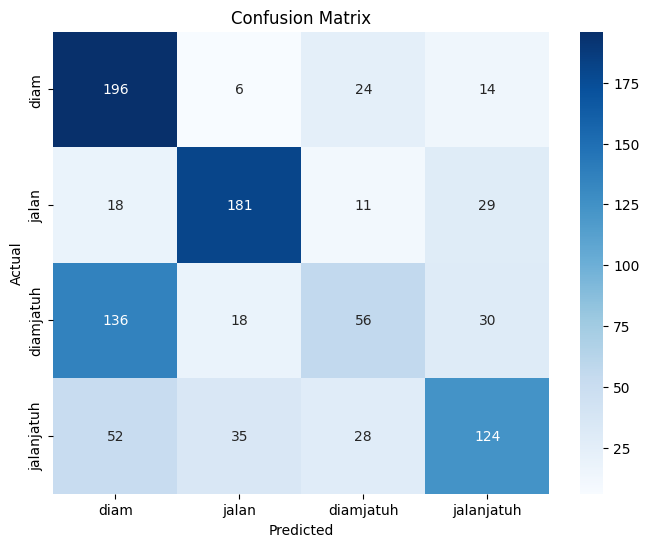

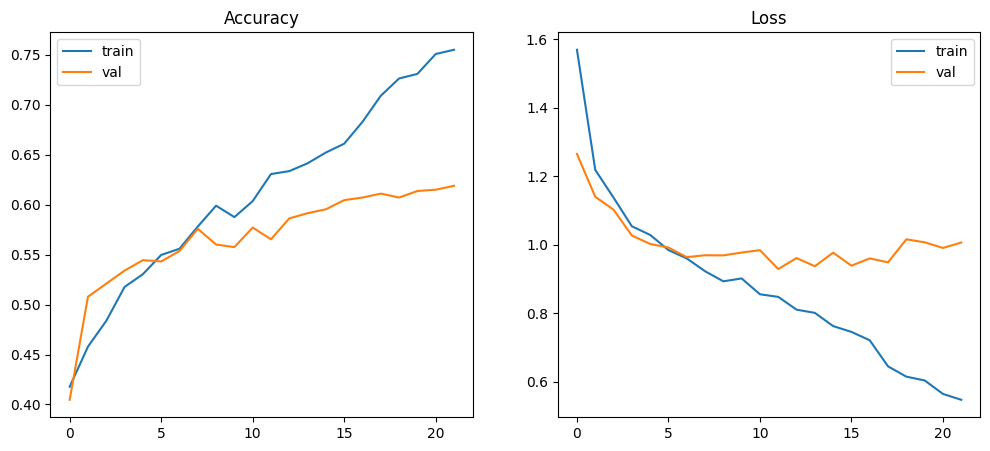

In [ ]:
# TRAINING CNN GYRO ONLY 200 OVERLAP 75%

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

path = "/content/drive/My Drive/Colab Notebooks/gyro_only_200_overlap75/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_gyro_only_200_overlap75.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(
    X_test,
    y_test
)

print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

KELAS : DIAM
gx -> Dominant Freq = 1.000 Hz | Power = 46.98169
gy -> Dominant Freq = 1.000 Hz | Power = 118.64668
gz -> Dominant Freq = 1.000 Hz | Power = 58.41555
Jumlah Window : 1197



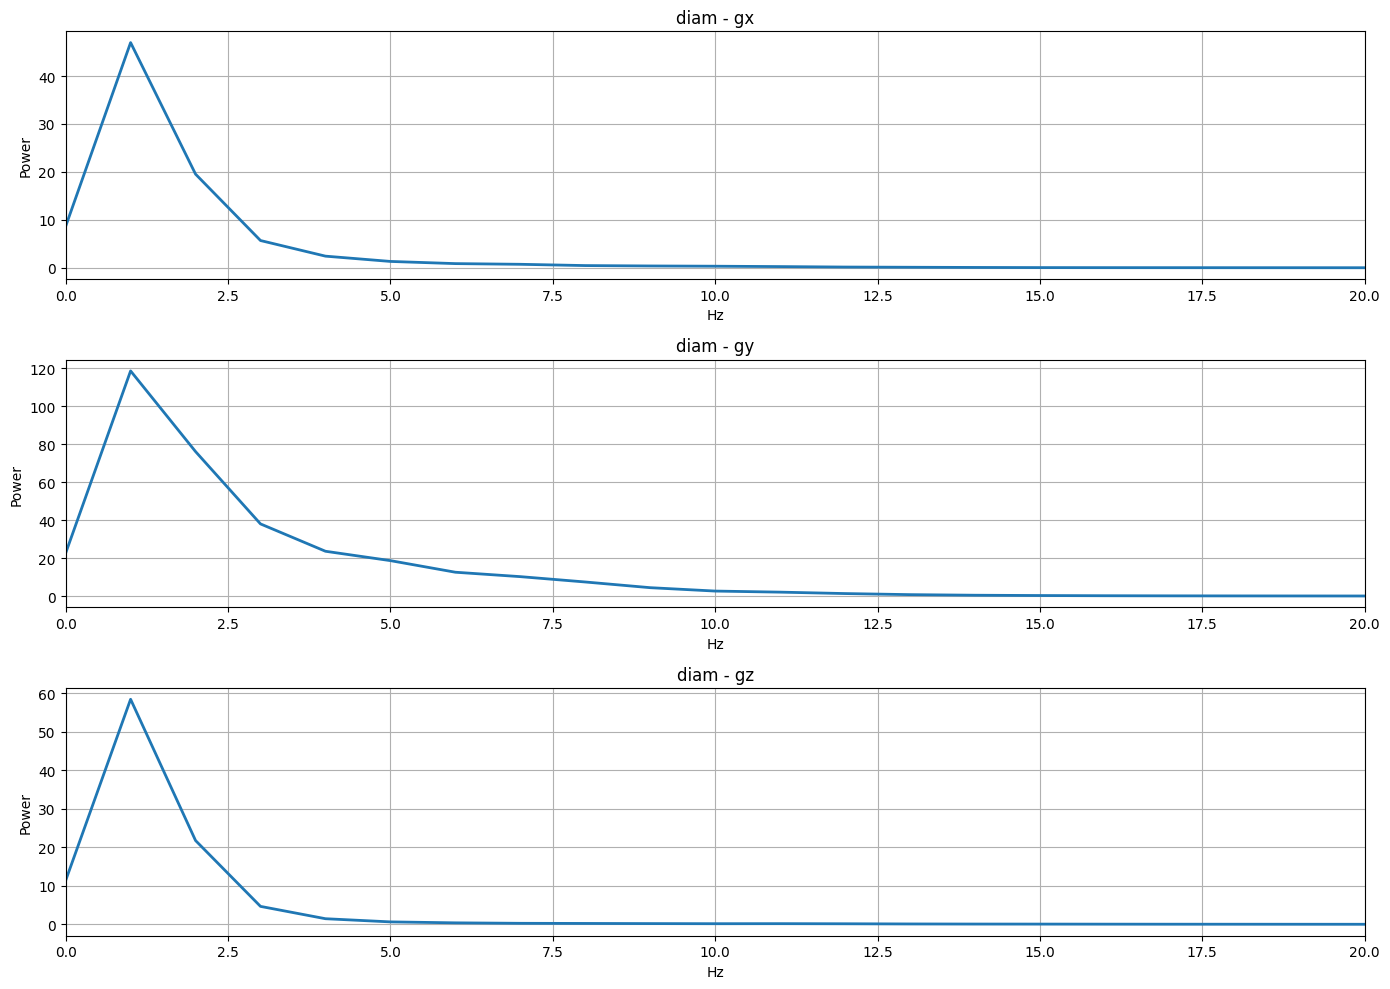

KELAS : JALAN
gx -> Dominant Freq = 1.000 Hz | Power = 533.69121
gy -> Dominant Freq = 1.000 Hz | Power = 1322.41966
gz -> Dominant Freq = 1.000 Hz | Power = 2289.17692
Jumlah Window : 1197



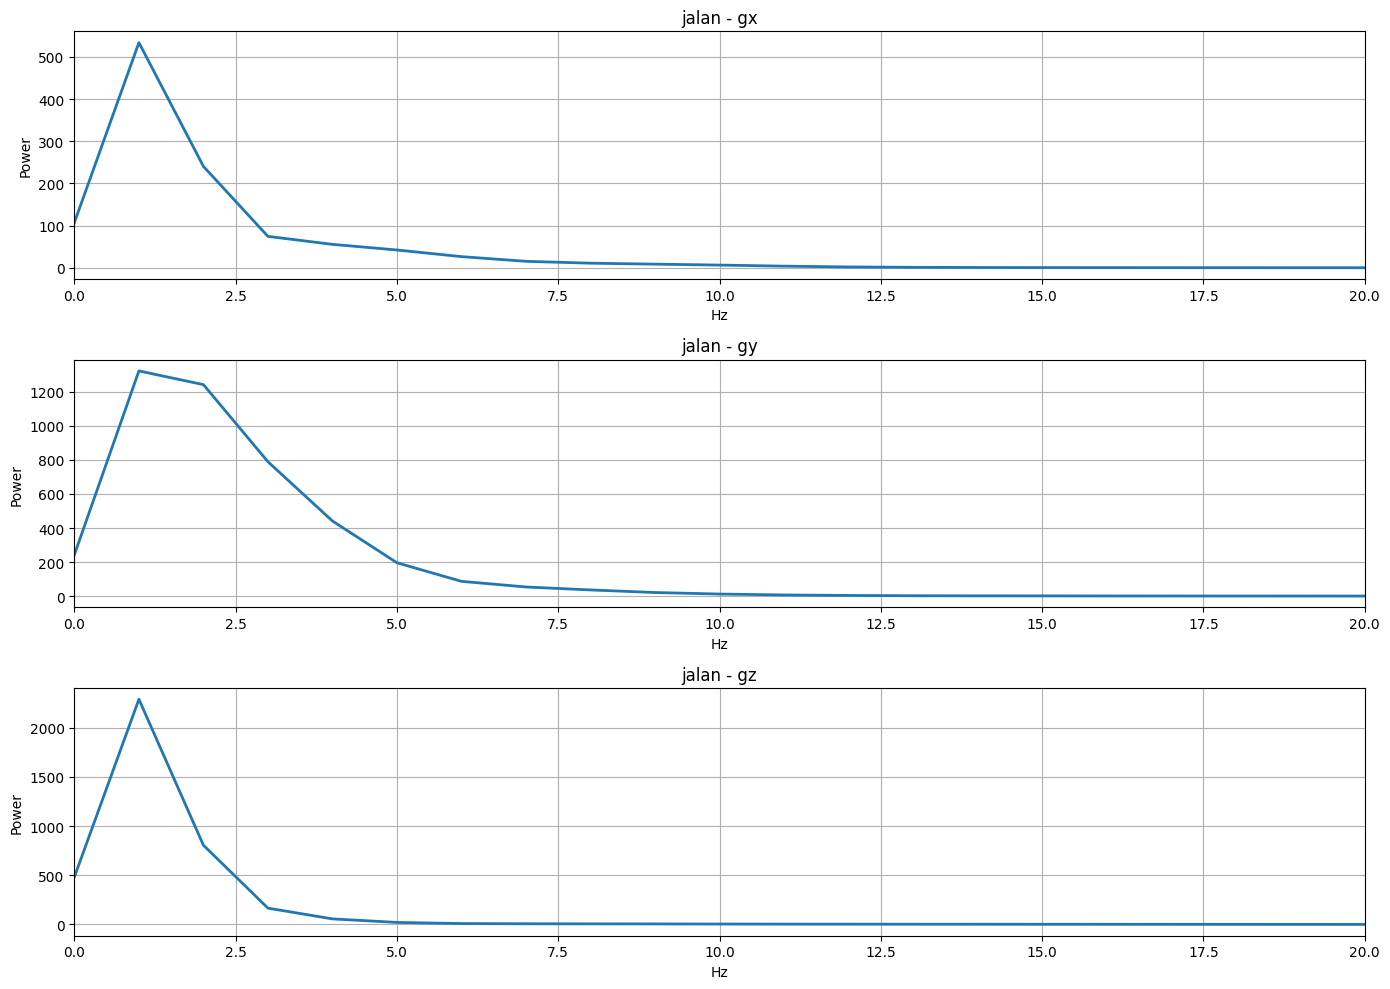

KELAS : DIAMJATUH
gx -> Dominant Freq = 1.000 Hz | Power = 331.73896
gy -> Dominant Freq = 1.000 Hz | Power = 501.23614
gz -> Dominant Freq = 1.000 Hz | Power = 344.62407
Jumlah Window : 1197



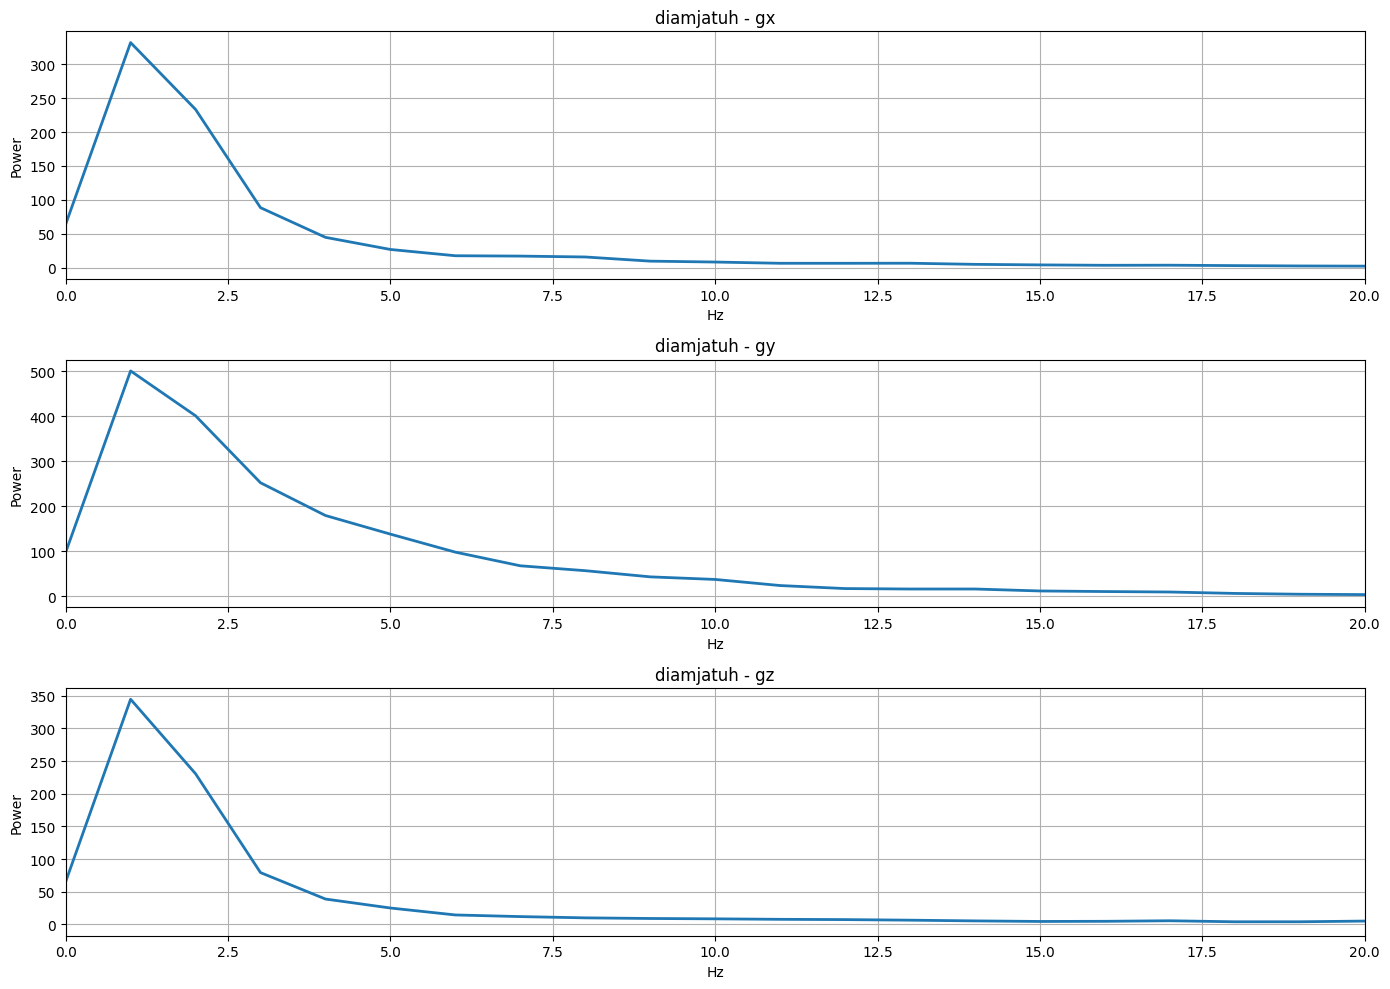

KELAS : JALANJATUH
gx -> Dominant Freq = 1.000 Hz | Power = 961.93321
gy -> Dominant Freq = 1.000 Hz | Power = 1301.01200
gz -> Dominant Freq = 1.000 Hz | Power = 2517.20689
Jumlah Window : 1197



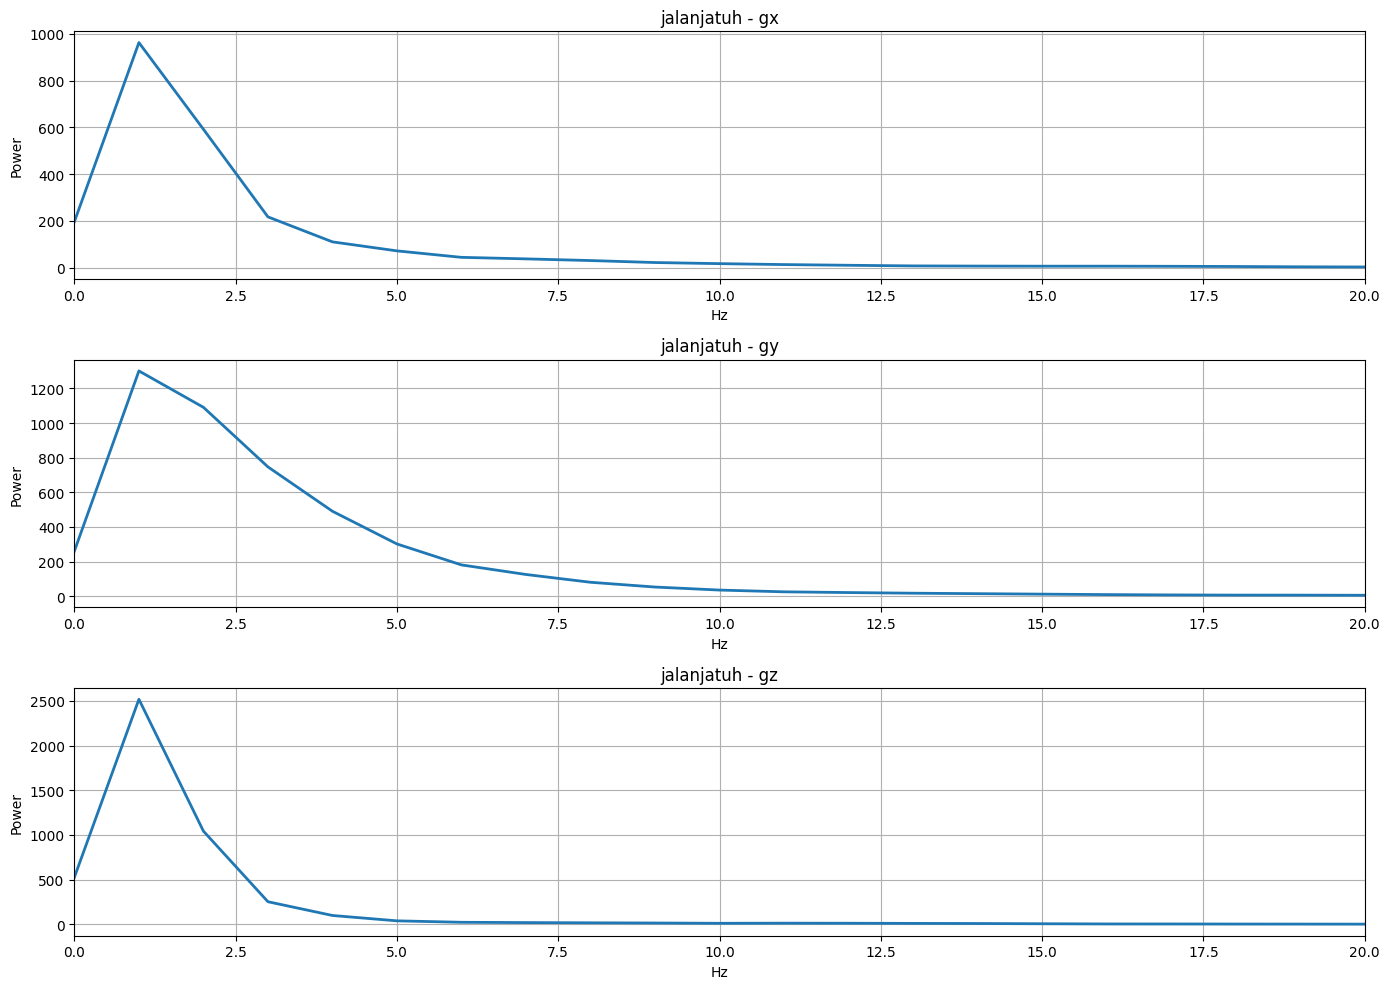

In [ ]:
# PSA GYRO ONLY
# WINDOW 200 OVERLAP 75%
# BEST MODEL ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.signal import welch

fs = 200

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"

kelas_list = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

channels = [
    "gx",
    "gy",
    "gz"
]

window = 200
stride = 50   # overlap 75%

for kelas in kelas_list:

    file = path + kelas + ".csv"

    df = pd.read_csv(file)

    data = df[channels].values

    print("KELAS :", kelas.upper())

    total_window = 0

    fig, axs = plt.subplots(3,1, figsize=(14,10))

    for ch_idx, ch in enumerate(channels):

        psd_all = []

        for i in range(0, len(data)-window+1, stride):

            segment = data[i:i+window, ch_idx]

            freq, psd = welch(
                segment,
                fs=fs,
                nperseg=window
            )

            psd_all.append(psd)
            total_window += 1 if ch_idx == 0 else 0

        psd_mean = np.mean(psd_all, axis=0)

        idx = np.argmax(psd_mean[1:]) + 1

        dom_freq = freq[idx]
        dom_power = psd_mean[idx]

        print(
            f"{ch} -> Dominant Freq = {dom_freq:.3f} Hz | Power = {dom_power:.5f}"
        )

        axs[ch_idx].plot(freq, psd_mean, linewidth=2)

        axs[ch_idx].set_title(f"{kelas} - {ch}")
        axs[ch_idx].set_xlabel("Hz")
        axs[ch_idx].set_ylabel("Power")
        axs[ch_idx].set_xlim(0,20)
        axs[ch_idx].grid(True)

    print("Jumlah Window :", total_window)
    print()

    plt.tight_layout()
    plt.show()

Shape X : (4788, 600)
Shape y : (4788,)


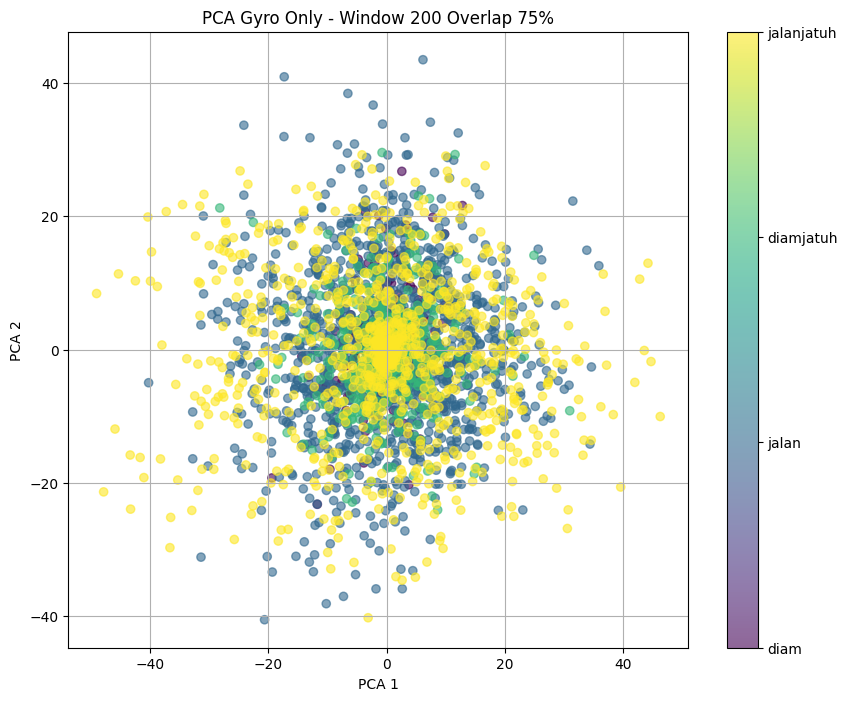

Explained Variance Ratio:
PC1 = 14.39 %
PC2 = 12.16 %
Total = 26.55 %


In [ ]:
# PCA GYRO ONLY
# WINDOW 200 OVERLAP 75%
# BEST MODEL VISUALIZATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/gyro_only/"

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

channels = [
    "gx",
    "gy",
    "gz"
]

window = 200
stride = 50   # overlap 75%

X = []
y = []

for kelas, label in kelas_files.items():

    file = path + kelas + ".csv"

    df = pd.read_csv(file)

    data = df[channels].values

    for i in range(0, len(data)-window+1, stride):

        segment = data[i:i+window]

        # flatten 200x3 -> 600 fitur
        fitur = segment.flatten()

        X.append(fitur)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Gyro Only - Window 200 Overlap 75%")
plt.grid(True)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0,1,2,3])
cbar.set_ticklabels([
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
])

plt.show()

# Explained Variance
print("Explained Variance Ratio:")
print("PC1 =", round(pca.explained_variance_ratio_[0]*100,2), "%")
print("PC2 =", round(pca.explained_variance_ratio_[1]*100,2), "%")
print("Total =", round(np.sum(pca.explained_variance_ratio_)*100,2), "%")